<a href="https://colab.research.google.com/github/Khushali-kavathiya/Python_Learning/blob/main/10_minutes_to_pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

In [2]:
import pandas as pd

Creating a Series by passing a list of values, letting pandas create a default RangeIndex.



In [6]:
s = pd.Series([1,3,5, np.nan, 6,8])

In [7]:
s

,0
0,1.0
1,3.0
2,5.0
3,NaN
4,6.0
5,8.0


Creating a DataFrame by passing a NumPy array with a datetime index using date_range() and labeled columns:

In [8]:
dates = pd.date_range("20130101", periods=6)

In [9]:
dates

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06'],
              dtype='datetime64[ns]', freq='D')

In [10]:
df = pd.DataFrame(np.random.randn(6,4), index=dates, columns=list("ABCD"))

In [11]:
df

,A,B,C,D
2013-01-01,-0.192260,2.028690,0.413672,0.308904
2013-01-02,-2.196267,1.083305,-1.454652,-1.483836
2013-01-03,-0.897390,0.549325,0.866152,-1.659166
2013-01-04,-0.404109,0.514180,0.577244,-0.430709
2013-01-05,-0.683538,-1.097894,1.662049,0.739040
2013-01-06,-1.266382,-0.766782,1.125785,0.231096


Creating a DataFrame by passing a dictionary of objects where the keys are the column labels and the values are the column values.

In [15]:
df2 = pd.DataFrame(
    {
      "A": 1.0,
      "B": pd.Timestamp("20130102"),
      "C": pd.Series(1, index=list(range(4)), dtype="float32"),
      "D": np.array([3] * 4, dtype="int32"),
      "E": pd.Categorical(["test", "train", "test", "train"]),
      "F": "foo",
    }
    )

In [16]:
df2

,A,B,C,D,E,F
0,1.0,2013-01-02,1.0,3,test,foo
1,1.0,2013-01-02,1.0,3,train,foo
2,1.0,2013-01-02,1.0,3,test,foo
3,1.0,2013-01-02,1.0,3,train,foo


In [17]:
df2.dtypes

,0
A,float64
B,datetime64[s]
C,float32
D,int32
E,category
F,object


# Viewing date

In [18]:
df.head()

,A,B,C,D
2013-01-01,-0.192260,2.028690,0.413672,0.308904
2013-01-02,-2.196267,1.083305,-1.454652,-1.483836
2013-01-03,-0.897390,0.549325,0.866152,-1.659166
2013-01-04,-0.404109,0.514180,0.577244,-0.430709
2013-01-05,-0.683538,-1.097894,1.662049,0.739040


In [19]:
df.tail(3)

,A,B,C,D
2013-01-04,-0.404109,0.514180,0.577244,-0.430709
2013-01-05,-0.683538,-1.097894,1.662049,0.739040
2013-01-06,-1.266382,-0.766782,1.125785,0.231096


Display the DataFrame.index or DataFrame.columns:

In [20]:
df.index

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06'],
              dtype='datetime64[ns]', freq='D')

In [22]:
df.columns

Index(['A', 'B', 'C', 'D'], dtype='object')

Return a NumPy representation of the underlying data with DataFrame.to_numpy() without the index or column labels:

In [21]:
df.to_numpy()

array([[-0.19226029,  2.0286897 ,  0.41367192,  0.30890401],
       [-2.19626657,  1.08330538, -1.45465216, -1.48383566],
       [-0.89739034,  0.54932454,  0.8661524 , -1.65916553],
       [-0.40410941,  0.51418012,  0.57724372, -0.43070912],
       [-0.68353838, -1.09789422,  1.66204861,  0.73903996],
       [-1.26638157, -0.766782  ,  1.12578461,  0.23109562]])

describe() shows a quick statistic summary of your data:

In [23]:
df.describe()

,A,B,C,D
count,6.000000,6.000000,6.000000,6.000000
mean,-0.939991,0.385137,0.531708,-0.382445
std,0.720918,1.162636,1.068090,0.995744
min,-2.196267,-1.097894,-1.454652,-1.659166
25%,-1.174134,-0.446541,0.454565,-1.220554
50%,-0.790464,0.531752,0.721698,-0.099807
75%,-0.473967,0.949810,1.060877,0.289452
max,-0.192260,2.028690,1.662049,0.739040


Transposing your data:

In [24]:
df.T

,2013-01-01,2013-01-02,2013-01-03,2013-01-04,2013-01-05,2013-01-06
A,-0.192260,-2.196267,-0.897390,-0.404109,-0.683538,-1.266382
B,2.028690,1.083305,0.549325,0.514180,-1.097894,-0.766782
C,0.413672,-1.454652,0.866152,0.577244,1.662049,1.125785
D,0.308904,-1.483836,-1.659166,-0.430709,0.739040,0.231096


DataFrame.sort_index() sorts by an axis:

In [25]:
df.sort_index(axis=1, ascending=False)

,D,C,B,A
2013-01-01,0.308904,0.413672,2.028690,-0.192260
2013-01-02,-1.483836,-1.454652,1.083305,-2.196267
2013-01-03,-1.659166,0.866152,0.549325,-0.897390
2013-01-04,-0.430709,0.577244,0.514180,-0.404109
2013-01-05,0.739040,1.662049,-1.097894,-0.683538
2013-01-06,0.231096,1.125785,-0.766782,-1.266382


DataFrame.sort_values() sorts by values:

In [29]:
df.sort_values(by="C")

,A,B,C,D
2013-01-02,-2.196267,1.083305,-1.454652,-1.483836
2013-01-01,-0.192260,2.028690,0.413672,0.308904
2013-01-04,-0.404109,0.514180,0.577244,-0.430709
2013-01-03,-0.897390,0.549325,0.866152,-1.659166
2013-01-06,-1.266382,-0.766782,1.125785,0.231096
2013-01-05,-0.683538,-1.097894,1.662049,0.739040


# Getitem

For a Dataframe, passing  single label selects a coloumn and yields a Series.

In [30]:
df["A"]

,A
2013-01-01,-0.192260
2013-01-02,-2.196267
2013-01-03,-0.897390
2013-01-04,-0.404109
2013-01-05,-0.683538
2013-01-06,-1.266382


If the label only contains letters, numbers, and underscores, you can alternatively use the column name attribute:

In [31]:
df.A

,A
2013-01-01,-0.192260
2013-01-02,-2.196267
2013-01-03,-0.897390
2013-01-04,-0.404109
2013-01-05,-0.683538
2013-01-06,-1.266382


Passing a list of column labels selects multiple columns, which can be useful for getting a subset/rearranging:

In [32]:
df[["B", "A"]]

,B,A
2013-01-01,2.028690,-0.192260
2013-01-02,1.083305,-2.196267
2013-01-03,0.549325,-0.897390
2013-01-04,0.514180,-0.404109
2013-01-05,-1.097894,-0.683538
2013-01-06,-0.766782,-1.266382


For a DataFrame, passing a slice : selects matching rows:

In [33]:
df[0:3]

,A,B,C,D
2013-01-01,-0.192260,2.028690,0.413672,0.308904
2013-01-02,-2.196267,1.083305,-1.454652,-1.483836
2013-01-03,-0.897390,0.549325,0.866152,-1.659166


In [34]:
df["20130102":"20130104"]

,A,B,C,D
2013-01-02,-2.196267,1.083305,-1.454652,-1.483836
2013-01-03,-0.897390,0.549325,0.866152,-1.659166
2013-01-04,-0.404109,0.514180,0.577244,-0.430709


# Selection by label

Selecting a row matching a label:

In [35]:
df.loc[dates[0]]

,2013-01-01
A,-0.192260
B,2.028690
C,0.413672
D,0.308904


Selecting a row matching a label:

In [36]:
df.loc[:, ["A", "B"]]

,A,B
2013-01-01,-0.192260,2.028690
2013-01-02,-2.196267,1.083305
2013-01-03,-0.897390,0.549325
2013-01-04,-0.404109,0.514180
2013-01-05,-0.683538,-1.097894
2013-01-06,-1.266382,-0.766782


For label slicing, both endpoints are included:



In [37]:
df.loc["20130102":"20130104", ["A", "B"]]

,A,B
2013-01-02,-2.196267,1.083305
2013-01-03,-0.897390,0.549325
2013-01-04,-0.404109,0.514180


Selecting a single row and column label returns a scalar:



In [38]:
df.loc[dates[0], "A"]

np.float64(-0.19226029086923915)

For getting fast access to a scalar (equivalent to the prior method):

In [39]:
df.at[dates[0], "A"]

np.float64(-0.19226029086923915)

# Selection by position

Select via the position of the passed integers:



In [40]:
df.iloc[3]

,2013-01-04
A,-0.404109
B,0.514180
C,0.577244
D,-0.430709


Integer slices acts similar to NumPy/Python:



In [41]:
df.iloc[3:5, 0:2]

,A,B
2013-01-04,-0.404109,0.514180
2013-01-05,-0.683538,-1.097894


Lists of integer position locations:



In [42]:
df.iloc[[1,2,4], [0,2]]

,A,C
2013-01-02,-2.196267,-1.454652
2013-01-03,-0.897390,0.866152
2013-01-05,-0.683538,1.662049


For slicing rows explicitly:



In [43]:
df.iloc[1:3, :]

,A,B,C,D
2013-01-02,-2.196267,1.083305,-1.454652,-1.483836
2013-01-03,-0.897390,0.549325,0.866152,-1.659166


For slicing columns explicitly:



In [44]:
df.iloc[:, 1:3]

,B,C
2013-01-01,2.028690,0.413672
2013-01-02,1.083305,-1.454652
2013-01-03,0.549325,0.866152
2013-01-04,0.514180,0.577244
2013-01-05,-1.097894,1.662049
2013-01-06,-0.766782,1.125785


For getting a value explicitly:



In [45]:
df.iloc[1,1]

np.float64(1.0833053758707611)

For getting fast access to a scalar (equivalent to the prior method):



In [46]:
df.iat[1,1]

np.float64(1.0833053758707611)

# Boolean indexing

In [50]:
df[df["A"] > 0]

,A,B,C,D


Selecting values from a DataFrame where a boolean condition is met:



In [49]:
df[df > 0]


,A,B,C,D
2013-01-01,NaN,2.028690,0.413672,0.308904
2013-01-02,NaN,1.083305,NaN,NaN
2013-01-03,NaN,0.549325,0.866152,NaN
2013-01-04,NaN,0.514180,0.577244,NaN
2013-01-05,NaN,NaN,1.662049,0.739040
2013-01-06,NaN,NaN,1.125785,0.231096


Using isin() method for filtering:



In [51]:
df2 = df.copy()

In [52]:
df2["E"] = ["one", "one", "two", "three", "four", "three"]

In [53]:
df2

,A,B,C,D,E
2013-01-01,-0.192260,2.028690,0.413672,0.308904,one
2013-01-02,-2.196267,1.083305,-1.454652,-1.483836,one
2013-01-03,-0.897390,0.549325,0.866152,-1.659166,two
2013-01-04,-0.404109,0.514180,0.577244,-0.430709,three
2013-01-05,-0.683538,-1.097894,1.662049,0.739040,four
2013-01-06,-1.266382,-0.766782,1.125785,0.231096,three


In [55]:
df[df2["E"].isin(["two", "four"])]

,A,B,C,D
2013-01-03,-0.897390,0.549325,0.866152,-1.659166
2013-01-05,-0.683538,-1.097894,1.662049,0.739040


# Setting

Setting a new column automatically aligns the data by the indexes:



In [56]:
s1 = pd.Series(
    [1,2,3,4,5,6],
    index=pd.date_range("20130102", periods=6)
)

In [57]:
s1

,0
2013-01-02,1
2013-01-03,2
2013-01-04,3
2013-01-05,4
2013-01-06,5
2013-01-07,6


In [58]:
df["F"] = s1

Setting values by label:

In [60]:
df.at[dates[0], "A"] = 0

Setting values by position:

In [61]:
df.iat[0,1] = 0

Setting by assigning with a NumPy array:



In [62]:
df.loc[:, "D"] = np.array([5] * len(df))

The result of the prior setting operations:



In [63]:
df

,A,B,C,D,F
2013-01-01,0.000000,0.000000,0.413672,5.0,NaN
2013-01-02,-2.196267,1.083305,-1.454652,5.0,1.0
2013-01-03,-0.897390,0.549325,0.866152,5.0,2.0
2013-01-04,-0.404109,0.514180,0.577244,5.0,3.0
2013-01-05,-0.683538,-1.097894,1.662049,5.0,4.0
2013-01-06,-1.266382,-0.766782,1.125785,5.0,5.0


A where operation with setting:



In [64]:
df2 = df.copy()

In [65]:
df2[df2 > 0] = -df2

In [66]:
df2

,A,B,C,D,F
2013-01-01,0.000000,0.000000,-0.413672,-5.0,NaN
2013-01-02,-2.196267,-1.083305,-1.454652,-5.0,-1.0
2013-01-03,-0.897390,-0.549325,-0.866152,-5.0,-2.0
2013-01-04,-0.404109,-0.514180,-0.577244,-5.0,-3.0
2013-01-05,-0.683538,-1.097894,-1.662049,-5.0,-4.0
2013-01-06,-1.266382,-0.766782,-1.125785,-5.0,-5.0


# Missing data

For NumPy data types, np.nan represents missing data. It is by default not included in computations.

Reindexing allows you to change/add/delete the index on a specified axis. This returns a copy of the data:

In [67]:
df1 = df.reindex(index=dates[0:4], columns=list(df.columns) + ["E"])

In [68]:
df1.loc[dates[0] : dates[1], "E"] = 1

In [69]:
df1

,A,B,C,D,F,E
2013-01-01,0.000000,0.000000,0.413672,5.0,NaN,1.0
2013-01-02,-2.196267,1.083305,-1.454652,5.0,1.0,1.0
2013-01-03,-0.897390,0.549325,0.866152,5.0,2.0,NaN
2013-01-04,-0.404109,0.514180,0.577244,5.0,3.0,NaN


DataFrame.dropna() drops any rows that have missing data:



In [70]:
df1.dropna(how="any")

,A,B,C,D,F,E
2013-01-02,-2.196267,1.083305,-1.454652,5.0,1.0,1.0


DataFrame.fillna() fills missing data:



In [71]:
df1.fillna(value=5)

,A,B,C,D,F,E
2013-01-01,0.000000,0.000000,0.413672,5.0,5.0,1.0
2013-01-02,-2.196267,1.083305,-1.454652,5.0,1.0,1.0
2013-01-03,-0.897390,0.549325,0.866152,5.0,2.0,5.0
2013-01-04,-0.404109,0.514180,0.577244,5.0,3.0,5.0


isna() gets the boolean mask where values are nan:



In [72]:
pd.isna(df1)

,A,B,C,D,F,E
2013-01-01,False,False,False,False,True,False
2013-01-02,False,False,False,False,False,False
2013-01-03,False,False,False,False,False,True
2013-01-04,False,False,False,False,False,True


# Operations

Stats

Operations in general exclude missing data.

Calculate the mean value for each column:

In [73]:
df.mean()

,0
A,-0.907948
B,0.047022
C,0.531708
D,5.000000
F,3.000000


Calculate the mean value for each row:



In [74]:
df.mean(axis=1)

,0
2013-01-01,1.353418
2013-01-02,0.686477
2013-01-03,1.503617
2013-01-04,1.737463
2013-01-05,1.776123
2013-01-06,1.818524


Operating with another Series or DataFrame with a different index or column will align the result with the union of the index or column labels. In addition, pandas automatically broadcasts along the specified dimension and will fill unaligned labels with np.nan.

In [78]:
s = pd.Series([1, 3, 5, np.nan, 6, 8], index=dates).shift(2)


In [79]:
s

,0
2013-01-01,NaN
2013-01-02,NaN
2013-01-03,1.0
2013-01-04,3.0
2013-01-05,5.0
2013-01-06,NaN


In [80]:
df.sub(s, axis="index")

,A,B,C,D,F
2013-01-01,NaN,NaN,NaN,NaN,NaN
2013-01-02,NaN,NaN,NaN,NaN,NaN
2013-01-03,-1.897390,-0.450675,-0.133848,4.0,1.0
2013-01-04,-3.404109,-2.485820,-2.422756,2.0,0.0
2013-01-05,-5.683538,-6.097894,-3.337951,0.0,-1.0
2013-01-06,NaN,NaN,NaN,NaN,NaN


# User defined functions

DataFrame.agg() and DataFrame.transform() applies a user defined function that reduces or broadcasts its result respectively.



In [81]:
df.agg(lambda x: np.mean(x) * 5.6)

,0
A,-5.084507
B,0.263325
C,2.977566
D,28.000000
F,16.800000


In [82]:
df.transform(lambda x: x * 101.2)

,A,B,C,D,F
2013-01-01,0.000000,0.000000,41.863598,506.0,NaN
2013-01-02,-222.262177,109.630504,-147.210798,506.0,101.2
2013-01-03,-90.815903,55.591643,87.654622,506.0,202.4
2013-01-04,-40.895873,52.035028,58.417065,506.0,303.6
2013-01-05,-69.174084,-111.106895,168.199320,506.0,404.8
2013-01-06,-128.157815,-77.598339,113.929403,506.0,506.0


# Value Counts

In [83]:
s = pd.Series(np.random.randint(0, 7, size=10))

In [84]:
s

,0
0,3
1,4
2,1
3,4
4,6
5,0
6,6
7,6
8,3
9,0


In [85]:
s.value_counts()

,count
6,3
3,2
4,2
0,2
1,1


# String Methods

Series is equipped with a set of string processing methods in the str attribute that make it easy to operate on each element of the array, as in the code snippet below.

In [86]:
s = pd.Series(["A", "B", "C", "Aaba", "Baca", np.nan, "CABA", "dog", "cat"])

In [87]:
s.str.lower()

,0
0,a
1,b
2,c
3,aaba
4,baca
5,NaN
6,caba
7,dog
8,cat


# Merge

# Concat

pandas provides various facilities for easily combining together Series and DataFrame objects with various kinds of set logic for the indexes and relational algebra functionality in the case of join / merge-type operations.

Concatenating pandas objects together row-wise with concat():



In [88]:
df = pd.DataFrame(np.random.randn(10, 4))

In [89]:
df

,0,1,2,3
0,0.154917,-0.815708,1.632338,1.088688
1,-2.125695,1.634775,0.399932,2.640682
2,2.396980,-0.687320,-0.534659,0.032142
3,0.455784,1.175080,0.085651,-0.252035
4,-1.328794,-0.473654,-0.698000,-1.249272
5,-0.464428,-1.700192,1.768121,0.496281
6,1.791895,-1.295780,0.626589,0.481864
7,-0.126602,0.604558,-1.139617,-0.286519
8,0.745643,0.794109,0.391988,-0.000265
9,0.055985,-1.227219,-0.483628,0.747365


In [90]:
pieces = [df[:3], df[3:7], df[7:]]

In [92]:
pieces

[          0         1         2         3
 0  0.154917 -0.815708  1.632338  1.088688
 1 -2.125695  1.634775  0.399932  2.640682
 2  2.396980 -0.687320 -0.534659  0.032142,
           0         1         2         3
 3  0.455784  1.175080  0.085651 -0.252035
 4 -1.328794 -0.473654 -0.698000 -1.249272
 5 -0.464428 -1.700192  1.768121  0.496281
 6  1.791895 -1.295780  0.626589  0.481864,
           0         1         2         3
 7 -0.126602  0.604558 -1.139617 -0.286519
 8  0.745643  0.794109  0.391988 -0.000265
 9  0.055985 -1.227219 -0.483628  0.747365]

In [91]:
pd.concat(pieces)

,0,1,2,3
0,0.154917,-0.815708,1.632338,1.088688
1,-2.125695,1.634775,0.399932,2.640682
2,2.396980,-0.687320,-0.534659,0.032142
3,0.455784,1.175080,0.085651,-0.252035
4,-1.328794,-0.473654,-0.698000,-1.249272
5,-0.464428,-1.700192,1.768121,0.496281
6,1.791895,-1.295780,0.626589,0.481864
7,-0.126602,0.604558,-1.139617,-0.286519
8,0.745643,0.794109,0.391988,-0.000265
9,0.055985,-1.227219,-0.483628,0.747365


# Join

merge() enables SQL style join types along specific columns. See the Database style joining section.



In [93]:
left = pd.DataFrame({"key": ["foo", "foo"], "lval": [1, 2]})

In [96]:
right = pd.DataFrame({"key": ["foo", "foo"], "rval": [4, 5]})

In [94]:
left

,key,lval
0,foo,1
1,foo,2


In [97]:
right

,key,rval
0,foo,4
1,foo,5


In [98]:
pd.merge(left, right, on="key")

,key,lval,rval
0,foo,1,4
1,foo,1,5
2,foo,2,4
3,foo,2,5


merge() on unique keys:



In [99]:
left = pd.DataFrame({"key": ["foo", "bar"], "lval": [1, 2]})


In [100]:
right = pd.DataFrame({"key": ["foo", "bar"], "rval": [4, 5]})


In [101]:
left

,key,lval
0,foo,1
1,bar,2


In [102]:
right

,key,rval
0,foo,4
1,bar,5


In [103]:
pd.merge(left, right, on="key")

,key,lval,rval
0,foo,1,4
1,bar,2,5


# Grouping

By “group by” we are referring to a process involving one or more of the following steps:

Splitting the data into groups based on some criteria

Applying a function to each group independently

Combining the results into a data structure

In [104]:
df = pd.DataFrame(
    {
        "A": ["foo", "bar", "foo", "bar", "foo", "bar", "foo", "foo"],
        "B": ["one", "one", "two", "three", "two", "two", "one", "three"],
        "C": np.random.randn(8),
        "D": np.random.randn(8),
    }
)

In [105]:
df

,A,B,C,D
0,foo,one,-1.416839,2.058761
1,bar,one,0.162999,0.040645
2,foo,two,-1.724384,-1.026125
3,bar,three,-0.340643,0.716225
4,foo,two,0.177558,0.187589
5,bar,two,-1.133463,-0.841524
6,foo,one,-2.112798,-2.378033
7,foo,three,1.820225,-1.482500


Grouping by a column label, selecting column labels, and then applying the DataFrameGroupBy.sum() function to the resulting groups:



In [106]:
df.groupby("A")[["C", "D"]].sum()

,C,D
A,,
bar,-1.311107,-0.084654
foo,-3.256238,-2.640308


Grouping by multiple columns label forms MultiIndex.



In [108]:
df.groupby(["A", "B"]).sum()

C         D
A   B                        
bar one    0.162999  0.040645
    three -0.340643  0.716225
    two   -1.133463 -0.841524
foo one   -3.529636 -0.319272
    three  1.820225 -1.482500
    two   -1.546826 -0.838536

# Reshaping

# Stack

In [109]:
arrays = [
   ["bar", "bar", "baz", "baz", "foo", "foo", "qux", "qux"],
   ["one", "two", "one", "two", "one", "two", "one", "two"],
]

In [112]:
index = pd.MultiIndex.from_arrays(arrays, names=["first", "second"])

In [113]:
df = pd.DataFrame(np.random.randn(8, 2), index=index, columns=["A", "B"])


In [114]:
df2 = df[:4]

In [115]:
df2

A         B
first second                    
bar   one     0.965476  0.653994
      two     0.331184  1.794967
baz   one    -0.682070  0.582642
      two    -0.649031 -0.333255

The stack() method “compresses” a level in the DataFrame’s columns:



In [116]:
stacked = df2.stack()
stacked

first  second   
bar    one     A    0.965476
               B    0.653994
       two     A    0.331184
               B    1.794967
baz    one     A   -0.682070
               B    0.582642
       two     A   -0.649031
               B   -0.333255
dtype: float64

With a “stacked” DataFrame or Series (having a MultiIndex as the index), the inverse operation of stack() is unstack(), which by default unstacks the last level:



In [117]:
stacked.unstack()

A         B
first second                    
bar   one     0.965476  0.653994
      two     0.331184  1.794967
baz   one    -0.682070  0.582642
      two    -0.649031 -0.333255

In [118]:
stacked.unstack(1)

second        one       two
first                      
bar   A  0.965476  0.331184
      B  0.653994  1.794967
baz   A -0.682070 -0.649031
      B  0.582642 -0.333255

In [119]:
stacked.unstack(0)

first          bar       baz
second                      
one    A  0.965476 -0.682070
       B  0.653994  0.582642
two    A  0.331184 -0.649031
       B  1.794967 -0.333255

# Pivot tables

In [120]:
df = pd.DataFrame(
    {
        "A": ["one", "one", "two", "three"] * 3,
        "B": ["A", "B", "C"] * 4,
        "C": ["foo", "foo", "foo", "bar", "bar", "bar"] * 2,
        "D": np.random.randn(12),
        "E": np.random.randn(12),
    }
)
df

,A,B,C,D,E
0,one,A,foo,-0.154696,-0.431153
1,one,B,foo,-0.001760,1.527220
2,two,C,foo,-0.696956,-0.116227
3,three,A,bar,-0.540657,-0.637930
4,one,B,bar,1.326066,2.323431
5,one,C,bar,-0.733742,-1.400522
6,two,A,foo,-0.718008,-1.702403
7,three,B,foo,1.482313,-1.200254
8,one,C,foo,-1.047011,0.442476
9,one,A,bar,-0.593202,1.334222


pivot_table() pivots a DataFrame specifying the values, index and columns



In [121]:
pd.pivot_table(df, values="D", index=["A", "B"], columns=["C"])

C             bar       foo
A     B                    
one   A -0.593202 -0.154696
      B  1.326066 -0.001760
      C -0.733742 -1.047011
three A -0.540657       NaN
      B       NaN  1.482313
      C  1.223040       NaN
two   A       NaN -0.718008
      B  2.405023       NaN
      C       NaN -0.696956

# Time series

In [122]:
rng = pd.date_range("1/1/2012", periods=100, freq="S")

/tmp/ipykernel_379/1178421381.py:1: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  rng = pd.date_range("1/1/2012", periods=100, freq="S")


In [123]:
ts = pd.Series(np.random.randint(0, 500, len(rng)), index=rng)

In [124]:
ts.resample("5Min").sum()

,0
2012-01-01,25215


Series.tz_localize() localizes a time series to a time zone:



In [125]:
rng = pd.date_range("3/6/2012 00:00", periods=5, freq="D")

In [126]:
ts = pd.Series(np.random.randn(len(rng)), rng)

In [127]:
ts

,0
2012-03-06,0.541550
2012-03-07,-1.002110
2012-03-08,2.131180
2012-03-09,0.040267
2012-03-10,-0.056372


In [128]:
ts_utc = ts.tz_localize("UTC")

In [129]:
ts_utc

,0
2012-03-06 00:00:00+00:00,0.541550
2012-03-07 00:00:00+00:00,-1.002110
2012-03-08 00:00:00+00:00,2.131180
2012-03-09 00:00:00+00:00,0.040267
2012-03-10 00:00:00+00:00,-0.056372


Series.tz_convert() converts a timezones aware time series to another time zone:



In [130]:
ts_utc.tz_convert("US/Eastern")


,0
2012-03-05 19:00:00-05:00,0.541550
2012-03-06 19:00:00-05:00,-1.002110
2012-03-07 19:00:00-05:00,2.131180
2012-03-08 19:00:00-05:00,0.040267
2012-03-09 19:00:00-05:00,-0.056372


Adding a non-fixed duration (BusinessDay) to a time series:



In [131]:
rng

DatetimeIndex(['2012-03-06', '2012-03-07', '2012-03-08', '2012-03-09',
               '2012-03-10'],
              dtype='datetime64[ns]', freq='D')

In [133]:
rng + pd.offsets.BusinessDay(5)

DatetimeIndex(['2012-03-13', '2012-03-14', '2012-03-15', '2012-03-16',
               '2012-03-16'],
              dtype='datetime64[ns]', freq=None)

# Categoricals

In [134]:
df = pd.DataFrame(
    {"id": [1, 2, 3, 4, 5, 6], "raw_grade": ["a", "b", "b", "a", "a", "e"]}
)

Converting the raw grades to a categorical data type:



In [135]:
df["grade"] = df["raw_grade"].astype("category")

In [136]:
df["grade"]

,grade
0,a
1,b
2,b
3,a
4,a
5,e


Rename the categories to more meaningful names:



In [137]:
new_categories = ["very good", "good", "very bad"]


In [138]:
df["grade"] = df["grade"].cat.rename_categories(new_categories)

Reorder the categories and simultaneously add the missing categories (methods under Series.cat() return a new Series by default):



In [139]:
df["grade"] = df["grade"].cat.set_categories(
    ["very bad", "bad", "medium", "good", "very good"]
)
df["grade"]

,grade
0,very good
1,good
2,good
3,very good
4,very good
5,very bad


Sorting is per order in the categories, not lexical order:



In [140]:
df.sort_values(by="grade")


,id,raw_grade,grade
5,6,e,very bad
1,2,b,good
2,3,b,good
0,1,a,very good
3,4,a,very good
4,5,a,very good


Grouping by a categorical column with observed=False also shows empty categories:



In [141]:
df.groupby("grade", observed=False).size()


,0
grade,
very bad,1
bad,0
medium,0
good,2
very good,3


# Plotting

We use the standard convention for referencing the matplotlib API:

In [142]:
import matplotlib.pyplot as plt

In [143]:
plt.close("all")

The plt.close method is used to close a figure window:

In [144]:
ts = pd.Series(np.random.randn(1000), index=pd.date_range("1/1/2000", periods=1000))

In [145]:
ts = ts.cumsum()

<Axes: >

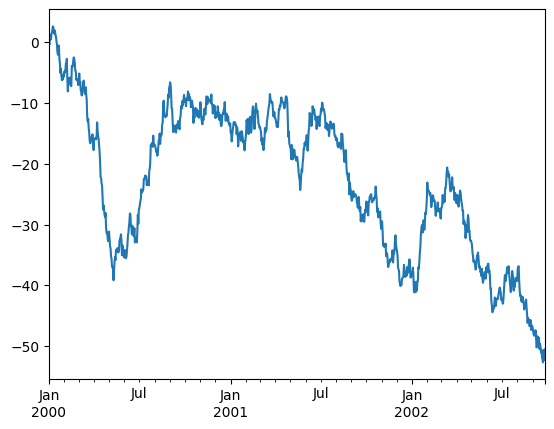

In [146]:
ts.plot()

plot() plots all columns:

<Figure size 640x480 with 0 Axes>

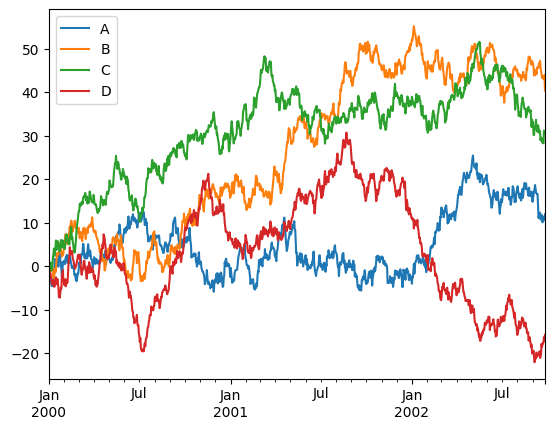

In [147]:
df = pd.DataFrame(
    np.random.randn(1000, 4), index=ts.index, columns=["A", "B", "C", "D"]
)

df = df.cumsum()

plt.figure();

df.plot();

plt.legend(loc='best');


 # Importing and exporting data

# CSV

In [148]:
df = pd.DataFrame(np.random.randint(0, 5, (10, 5)))

In [149]:
df.to_csv("foo.csv")

In [150]:
pd.read_csv("foo.csv")

,Unnamed: 0,0,1,2,3,4
0,0,3,2,1,0,0
1,1,1,0,4,1,0
2,2,2,3,4,3,1
3,3,3,4,1,4,1
4,4,2,4,0,4,2
5,5,4,3,4,3,4
6,6,0,4,2,1,3
7,7,2,1,3,4,4
8,8,3,0,2,4,4
9,9,4,2,2,0,3


# Parquet

Writing to a Parquet file:



In [151]:
df.to_parquet("foo.parquet")


In [152]:
pd.read_parquet("foo.parquet")


,0,1,2,3,4
0,3,2,1,0,0
1,1,0,4,1,0
2,2,3,4,3,1
3,3,4,1,4,1
4,2,4,0,4,2
5,4,3,4,3,4
6,0,4,2,1,3
7,2,1,3,4,4
8,3,0,2,4,4
9,4,2,2,0,3


# Excel

Writing to an excel file using DataFrame.to_excel():


In [154]:
df.to_excel("foo.xlsx", sheet_name="Sheet1")


In [155]:
pd.read_excel("foo.xlsx", "Sheet1", index_col=None, na_values=["NA"])


,Unnamed: 0,0,1,2,3,4
0,0,3,2,1,0,0
1,1,1,0,4,1,0
2,2,2,3,4,3,1
3,3,3,4,1,4,1
4,4,2,4,0,4,2
5,5,4,3,4,3,4
6,6,0,4,2,1,3
7,7,2,1,3,4,4
8,8,3,0,2,4,4
9,9,4,2,2,0,3
